# Model ID (finger) — kinematic fitting

Fits the linear transmission model q = k·θ for MCP and PIP joints from
recorded (θ, q) pairs. Saves fitted coefficients to `finger_params.py`.

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd
import os
import re

# Load custom plot style
plt.style.use(['science', '../plot_config.mplstyle'])

In [2]:
def fit_linear_model(data):
    """
    Fit q = k * theta to data points (linear approximation).
    
    Parameters:
    -----------
    data : list of tuples
        List of (q, theta) pairs where both q and theta are in radians
    
    Returns:
    --------
    dict : {'k': float, 'mse': float, 'r_squared': float}
    """
    
    # Define MSE cost function
    def mse_cost(k):
        mse = 0
        for q_meas, theta_meas in data:
            q_pred = k * theta_meas
            mse += (q_pred - q_meas)**2
        
        return mse / len(data)
    
    # Initial guess
    initial_guess = [1.0]
    
    # Minimize MSE
    result = minimize(mse_cost, initial_guess, method='L-BFGS-B')
    
    k_sol = result.x[0]
    
    # Calculate R² (coefficient of determination)
    q_values = [q for q, _ in data]
    q_mean = np.mean(q_values)
    ss_tot = sum((q - q_mean)**2 for q in q_values)
    ss_res = sum((q - k_sol * theta)**2 for q, theta in data)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Print results
    print(f"k = {k_sol:.6f}")
    print(f"MSE = {result.fun:.6f}")
    print(f"R² = {r_squared:.6f}")
    
    # Verify predictions
    print(f"\nVerification:")
    for q_meas, theta_meas in data:
        q_pred = k_sol * theta_meas
        error_deg = np.degrees(abs(q_pred - q_meas))
        error_pct = 100 * abs(q_pred - q_meas) / abs(q_meas) if q_meas != 0 else 0
        print(f"theta={np.degrees(theta_meas):5.1f}° ({theta_meas:.4f} rad): "
              f"measured q={np.degrees(q_meas):6.1f}° ({q_meas:.4f} rad), "
              f"predicted q={np.degrees(q_pred):6.1f}° ({q_pred:.4f} rad), "
              f"error={error_deg:.2f}° ({error_pct:.1f}%)")
    
    return {
        'k': k_sol,
        'mse': result.fun,
        'r_squared': r_squared
    }

In [3]:
def plot_model_fit(data, k, title="Linear Model Fit", equation_label=r'$q = k \cdot \theta$',
                   color_fit='C0', color_data='C1', xlabel=r'$\theta$ [$^\circ$]'):
    """
    Plot the measured data and fitted model.
    
    Parameters:
    -----------
    data : list of tuples
        List of (q, theta) pairs in radians
    k : float
        Fitted parameter from q = k * theta
    title : str
        Title to print (not shown on plot)
    equation_label : str
        LaTeX equation to show in legend
    color_fit : str
        Color for fitted line (default 'C0' = Blue from config)
    color_data : str
        Color for measured data (default 'C1' = Orange from config)
    xlabel : str
        Label for x-axis (default: theta)
    """
    
    # Print title instead of showing on plot
    print(f"\n{title}")
    print("=" * len(title))
    
    # Extract data
    q_meas = [q for q, _ in data]
    theta_meas = [theta for _, theta in data]
    
    # Convert to degrees for plotting
    q_meas_deg = np.degrees(q_meas)
    theta_meas_deg = np.degrees(theta_meas)
    
    # Create fitted line
    theta_fit = np.linspace(0, max(theta_meas), 100)
    q_fit = k * theta_fit
    theta_fit_deg = np.degrees(theta_fit)
    q_fit_deg = np.degrees(q_fit)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot with specified colors from plot_config.mplstyle
    ax.plot(theta_fit_deg, q_fit_deg, '--', 
            color=color_fit, label=equation_label, linewidth=2.5)
    ax.plot(theta_meas_deg, q_meas_deg, 'o', 
            color=color_data, markersize=10, label='Measures')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$q$ ($^\circ$)')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## PIP Joint Data

Fit the linear model to PIP joint data

In [4]:
# Load joint data from CSV (degrees only, convert to radians here)
def load_joint_data_from_csv(filename):
    """Load joint data (q_deg, theta_deg) from CSV and convert to radians."""
    filepath = os.path.join('outputs/joint_data', filename)
    df = pd.read_csv(filepath)
    data = [(np.radians(row['q_deg']), np.radians(row['theta_deg'])) for _, row in df.iterrows()]
    print(f"Loaded {len(data)} points from {filepath}")
    return data

In [5]:
# Load PIP joint data from CSV
data_pip = load_joint_data_from_csv('pip_joint_data.csv')

# Fit the model
results_pip = fit_linear_model(data_pip)

# Print final result
print(f"\nFinal result:")
print(f"q = {results_pip['k']:.6f} * theta")
print(f"For c/r_motor form: c/r_motor = {results_pip['k']:.6f}")
print(f"If r_motor = 0.005 m, then c = {results_pip['k'] * 0.005:.6f} m")

Loaded 6 points from outputs/joint_data/pip_joint_data.csv
k = 1.626606
MSE = 0.001673
R² = 0.996897

Verification:
theta=  0.0° (0.0000 rad): measured q=   0.0° (0.0000 rad), predicted q=   0.0° (0.0000 rad), error=0.00° (0.0%)
theta= 15.0° (0.2618 rad): measured q=  25.7° (0.4479 rad), predicted q=  24.4° (0.4258 rad), error=1.26° (4.9%)
theta= 30.0° (0.5236 rad): measured q=  48.1° (0.8388 rad), predicted q=  48.8° (0.8517 rad), error=0.74° (1.5%)
theta= 45.0° (0.7854 rad): measured q=  68.8° (1.2013 rad), predicted q=  73.2° (1.2775 rad), error=4.37° (6.3%)
theta= 60.0° (1.0472 rad): measured q=  96.8° (1.6890 rad), predicted q=  97.6° (1.7034 rad), error=0.83° (0.9%)
theta= 75.0° (1.3090 rad): measured q= 125.3° (2.1872 rad), predicted q= 122.0° (2.1292 rad), error=3.32° (2.7%)

Final result:
q = 1.626606 * theta
For c/r_motor form: c/r_motor = 1.626606
If r_motor = 0.005 m, then c = 0.008133 m



PIP Joint: Linear Model Fit


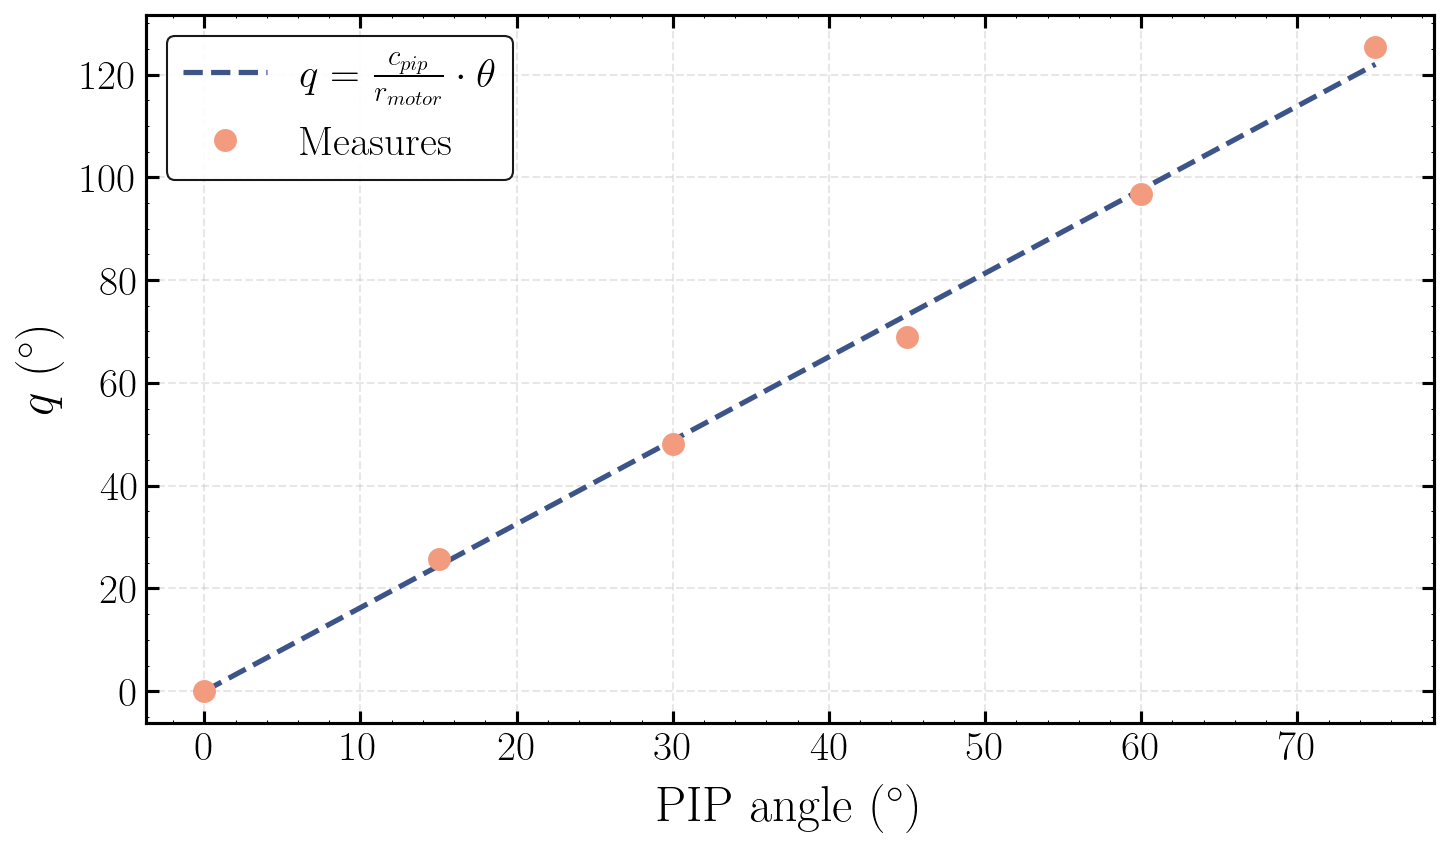

In [6]:
# Plot PIP joint results
plot_model_fit(data_pip, results_pip['k'], 
               title="PIP Joint: Linear Model Fit",
               equation_label=r'$q = \frac{c_{pip}}{r_{motor}} \cdot \theta$',
               color_fit='C3', color_data='C4',
               xlabel=r'PIP angle ($^\circ$)')

## MCP Joint Data

Fit the linear model to MCP joint data

In [7]:
# Load MCP joint data from CSV
data_mcp = load_joint_data_from_csv('mcp_joint_data.csv')

# Fit the model
results_mcp = fit_linear_model(data_mcp)

# Print final result
print(f"\nFinal result:")
print(f"q = {results_mcp['k']:.6f} * theta")
print(f"For r_motor/r_pulley form: r_motor/r_pulley = {results_mcp['k']:.6f}")
print(f"If r_motor = 0.005 m, then r_pulley = {0.005 / results_mcp['k']:.6f} m")

Loaded 6 points from outputs/joint_data/mcp_joint_data.csv
k = 2.242533
MSE = 0.003751
R² = 0.996102

Verification:
theta=  0.0° (0.0000 rad): measured q=   0.0° (0.0000 rad), predicted q=   0.0° (0.0000 rad), error=0.00° (0.0%)
theta= 15.0° (0.2618 rad): measured q=  40.1° (0.6994 rad), predicted q=  33.6° (0.5871 rad), error=6.43° (16.1%)
theta= 30.0° (0.5236 rad): measured q=  70.0° (1.2210 rad), predicted q=  67.3° (1.1742 rad), error=2.68° (3.8%)
theta= 45.0° (0.7854 rad): measured q=  99.9° (1.7441 rad), predicted q= 100.9° (1.7613 rad), error=0.98° (1.0%)
theta= 60.0° (1.0472 rad): measured q= 130.0° (2.2688 rad), predicted q= 134.6° (2.3484 rad), error=4.56° (3.5%)
theta= 75.0° (1.3090 rad): measured q= 170.1° (2.9683 rad), predicted q= 168.2° (2.9355 rad), error=1.88° (1.1%)

Final result:
q = 2.242533 * theta
For r_motor/r_pulley form: r_motor/r_pulley = 2.242533
If r_motor = 0.005 m, then r_pulley = 0.002230 m



MCP Joint: Linear Model Fit


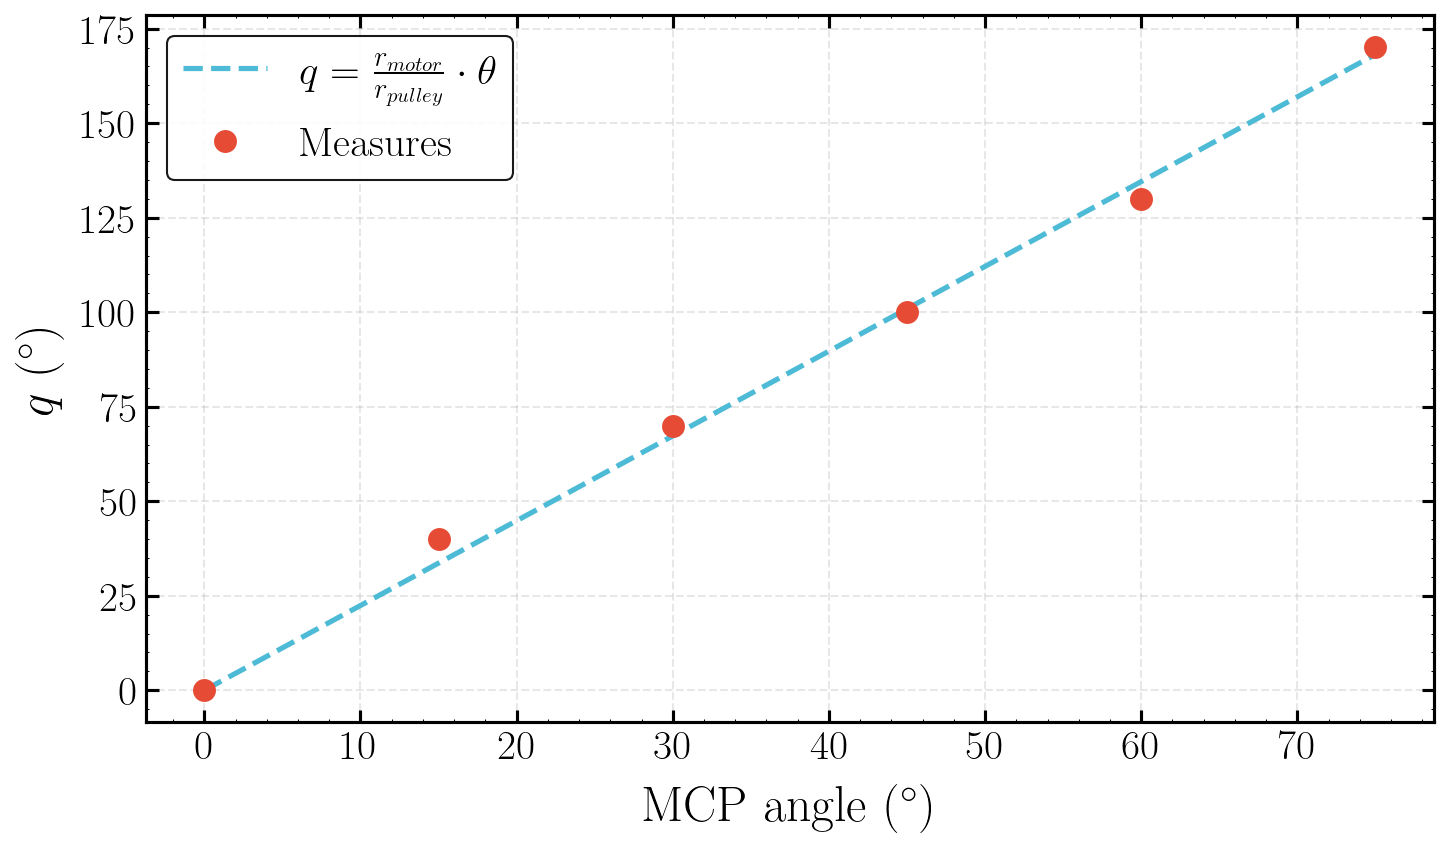

In [8]:
# Plot MCP joint results
plot_model_fit(data_mcp, results_mcp['k'], 
               title="MCP Joint: Linear Model Fit",
               equation_label=r'$q = \frac{r_{motor}}{r_{pulley}} \cdot \theta$',
               color_fit='C0', color_data='C1',
               xlabel=r'MCP angle ($^\circ$)')

## Save fitted parameters to finger_params.py

In [9]:
# Compute physical parameters from fitted k values
r_motor = 0.005
r_pulley_fitted = r_motor / results_mcp['k']
c_param_fitted  = results_pip['k'] * r_motor

print(f"Fitted parameters:")
print(f"  r_pulley = {r_pulley_fitted:.5f} m  (from MCP: r_motor / k = {r_motor} / {results_mcp['k']:.6f})")
print(f"  c_param  = {c_param_fitted:.5f} m  (from PIP: k * r_motor = {results_pip['k']:.6f} * {r_motor})")

# Update finger_params.py
params_path = 'finger_params.py'

with open(params_path, 'r') as f:
    content = f.read()

content = re.sub(
    r'(r_pulley\s*=\s*)[\d.]+',
    lambda m: f'{m.group(1)}{r_pulley_fitted:.5f}',
    content
)
content = re.sub(
    r'(c_param\s*=\s*)[\d.]+',
    lambda m: f'{m.group(1)}{c_param_fitted:.5f}',
    content
)

with open(params_path, 'w') as f:
    f.write(content)

print(f"\nParameters saved to {params_path}")

Fitted parameters:
  r_pulley = 0.00223 m  (from MCP: r_motor / k = 0.005 / 2.242533)
  c_param  = 0.00813 m  (from PIP: k * r_motor = 1.626606 * 0.005)

Parameters saved to finger_params.py
